In [1]:
import os
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. BIOLOGICAL DICTIONARY & GENOME COORDINATES
# ==============================================================================
# Codons (3-letter nucleotide words) translate to Amino Acids (ingredients)
GENETIC_CODE = {
    'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M', 'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
    'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K', 'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',
    'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L', 'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
    'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q', 'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
    'GTA':'V', 'GTC':'V', 'GTG':'V', 'GTT':'V', 'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
    'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E', 'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
    'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S', 'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'L',
    'TAC':'Y', 'TAT':'Y', 'TAA':'*', 'TAG':'*', 'TGC':'C', 'TGT':'C', 'TGA':'*', 'TGG':'W',
}

# SARS-CoV-2 gene locations (1-based genomic coordinates on NC_045512.2)
VIRAL_GENES = [
    {"gene": "ORF1ab (Replication Engine)", "start": 266, "end": 21555},
    {"gene": "S (Spike Surface Disguise)",  "start": 21563, "end": 25384},
    {"gene": "E (Envelope)",                "start": 26245, "end": 26472},
    {"gene": "M (Membrane)",                "start": 26523, "end": 27191},
    {"gene": "N (Nucleocapsid)",            "start": 28274, "end": 29533}
]

# ==============================================================================
# 2. STEP 1: FETCH & PARSE GENOMES
# ==============================================================================
def download_genome(accession_id, filename):
    """Downloads a raw FASTA record directly from NCBI."""
    url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={accession_id}&rettype=fasta&retmode=text"
    if not os.path.exists(filename):
        print(f"[*] Downloading {accession_id} to {filename}...")
        urllib.request.urlretrieve(url, filename)
    else:
        print(f"[+] Found cached file: {filename}")

def parse_fasta(filepath):
    """Reads a FASTA file and returns the clean nucleotide sequence."""
    sequence = []
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line.startswith(">"):
                sequence.append(line.upper())
    return "".join(sequence)

# ==============================================================================
# 3. STEP 2: FIND TYPOS & TRANSLATE THEIR MEANING
# ==============================================================================
def get_gene_name(pos):
    """Identifies which gene a 1-based genome coordinate belongs to."""
    for g in VIRAL_GENES:
        if g["start"] <= pos <= g["end"]:
            return g
    return None

def analyze_mutations(ref_seq, var_seq):
    """
    Compares the original recipe (ref) with the new variant letter-by-letter.
    Classifies each typo as:
      - Synonymous: Harmless typo (same amino acid)
      - Missense: Meaning changed (different amino acid)
    """
    min_len = min(len(ref_seq), len(var_seq))
    findings = []

    print("[*] Scanning genomes for spelling mistakes...")
    for i in range(min_len):
        ref_base = ref_seq[i]
        var_base = var_seq[i]
        pos = i + 1  # 1-indexed biology convention

        # Ignore identical bases and ambiguous sequencing markers ('N' or gaps)
        if ref_base == var_base or ref_base in ("N", "-") or var_base in ("N", "-"):
            continue

        gene = get_gene_name(pos)
        if not gene:
            findings.append({
                "Position": pos,
                "Gene": "Non-coding / Intergenic",
                "Mutation": f"{ref_base}{pos}{var_base}",
                "Impact": "Non-coding",
                "AA_Change": "-"
            })
            continue

        # Calculate where this letter sits in its 3-letter codon word
        cds_start_idx = gene["start"] - 1
        offset_in_gene = i - cds_start_idx
        codon_offset = offset_in_gene % 3
        
        # Extract the original triplet codon and construct the new mutant codon
        codon_start = i - codon_offset
        ref_codon = ref_seq[codon_start : codon_start + 3]
        var_codon = list(ref_codon)
        var_codon[codon_offset] = var_base
        var_codon = "".join(var_codon)

        ref_aa = GENETIC_CODE.get(ref_codon, "?")
        var_aa = GENETIC_CODE.get(var_codon, "?")
        aa_num = (offset_in_gene // 3) + 1

        # Check whether the protein ingredient changed
        if ref_aa == var_aa:
            impact = "Synonymous (Silent)"
            aa_change = f"p.{ref_aa}{aa_num}{var_aa}"
        else:
            impact = "Missense (Changed)"
            aa_change = f"p.{ref_aa}{aa_num}{var_aa}"

        findings.append({
            "Position": pos,
            "Gene": gene["gene"],
            "Mutation": f"{ref_base}{pos}{var_base}",
            "Impact": impact,
            "AA_Change": aa_change
        })

    return pd.DataFrame(findings)

# ==============================================================================
# 4. STEP 3: MEASURE EVOLUTIONARY PRESSURE (dN/dS)
# ==============================================================================
def count_potential_sites(codon):
    """Counts how many of the 9 possible single-letter changes to this codon are silent vs missense."""
    ref_aa = GENETIC_CODE.get(codon, None)
    if not ref_aa or ref_aa == "*":
        return 0.0, 0.0

    syn_opportunities = 0
    mis_opportunities = 0

    for pos in range(3):
        orig_base = codon[pos]
        for alt in ['A', 'C', 'G', 'T']:
            if alt == orig_base:
                continue
            mutant_codon = list(codon)
            mutant_codon[pos] = alt
            alt_aa = GENETIC_CODE.get("".join(mutant_codon), None)
            
            if alt_aa == ref_aa:
                syn_opportunities += 1
            else:
                mis_opportunities += 1

    return syn_opportunities / 3.0, mis_opportunities / 3.0

def calculate_dnds_table(ref_seq, df_mutations):
    """Calculates the dN/dS ratio to test whether a gene is mutating to adapt or staying conserved."""
    # Filter observed counts
    coding = df_mutations[df_mutations["Impact"].isin(["Missense (Changed)", "Synonymous (Silent)"])]
    observed = pd.crosstab(coding["Gene"], coding["Impact"])

    summary = []
    for g in VIRAL_GENES:
        gene_name = g["gene"]
        cds = ref_seq[g["start"] - 1 : g["end"]]
        
        # Sum total mutational opportunities
        total_s_sites = 0.0
        total_n_sites = 0.0
        for idx in range(0, len(cds) - 2, 3):
            codon = cds[idx : idx + 3]
            s, n = count_potential_sites(codon)
            total_s_sites += s
            total_n_sites += n

        obs_n = observed.loc[gene_name, "Missense (Changed)"] if (gene_name in observed.index and "Missense (Changed)" in observed.columns) else 0
        obs_s = observed.loc[gene_name, "Synonymous (Silent)"] if (gene_name in observed.index and "Synonymous (Silent)" in observed.columns) else 0

        # Compute normalized rates
        dN = obs_n / total_n_sites if total_n_sites > 0 else 0.0
        dS = obs_s / total_s_sites if total_s_sites > 0 else 0.0
        
        if dS > 0:
            dnds = round(dN / dS, 2)
            regime = "Positive Selection (Adapting/Evading)" if dnds > 1.0 else "Purifying Selection (Conserved)"
        else:
            dnds = None
            regime = "Undefined (No silent mutations)"

        summary.append({
            "Gene": gene_name,
            "Observed_Missense": obs_n,
            "Observed_Silent": obs_s,
            "dN": round(dN, 5),
            "dS": round(dS, 5),
            "dN/dS": dnds,
            "Evolutionary_Status": regime
        })

    return pd.DataFrame(summary)

# ==============================================================================
# 5. STEP 4: VISUALIZATION
# ==============================================================================
def generate_chart(df_mutations):
    """Creates a stacked bar plot of Missense vs Synonymous mutations per gene."""
    coding_df = df_mutations[df_mutations["Impact"].isin(["Missense (Changed)", "Synonymous (Silent)"])]
    if coding_df.empty:
        print("[!] No coding mutations to plot.")
        return

    counts = pd.crosstab(coding_df["Gene"], coding_df["Impact"])
    for col in ["Missense (Changed)", "Synonymous (Silent)"]:
        if col not in counts.columns:
            counts[col] = 0

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(9, 5))

    palette = {"Missense (Changed)": "#e63946", "Synonymous (Silent)": "#457b9d"}
    counts.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[palette[col] for col in counts.columns],
        edgecolor="black",
        width=0.65
    )

    ax.set_title("Distribution of Meaningful vs. Silent Mutations Across Viral Genes", weight="bold", pad=12)
    ax.set_xlabel("Viral Gene", weight="bold")
    ax.set_ylabel("Mutation Count", weight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.legend(title="Mutation Consequence")

    plt.tight_layout()
    plt.savefig("mutation_breakdown.png", dpi=300)
    plt.close()
    print("[+] Saved visualization to 'mutation_breakdown.png'")

# ==============================================================================
# MAIN PIPELINE EXECUTION
# ==============================================================================
if __name__ == "__main__":
    os.makedirs("data", exist_ok=True)
    ref_file = "data/reference.fasta"
    var_file = "data/variant.fasta"

    # NC_045512.2 = Wuhan-Hu-1 Original Reference
    # MW931310.1  = Delta lineage sample isolate
    download_genome("NC_045512.2", ref_file)
    download_genome("MW931310.1", var_file)

    ref_sequence = parse_fasta(ref_file)
    var_sequence = parse_fasta(var_file)

    # 1. Detect and annotate typos
    df_results = analyze_mutations(ref_sequence, var_sequence)
    df_results.to_csv("mutations_report.csv", index=False)
    print(f"\n[+] Detected {len(df_results)} total point mutations.")
    print("\nSample of detected mutations:")
    print(df_results.head())

    # 2. Calculate evolutionary selection
    print("\n[*] Calculating evolutionary pressure (dN/dS)...")
    df_dnds = calculate_dnds_table(ref_sequence, df_results)
    print("\n--- EVOLUTIONARY SELECTION REPORT ---")
    print(df_dnds[["Gene", "Observed_Missense", "Observed_Silent", "dN/dS", "Evolutionary_Status"]].to_string(index=False))

    # 3. Plot
    generate_chart(df_results)
    print("\n[✓] Analysis pipeline finished successfully!")

[*] Downloading NC_045512.2 to data/reference.fasta...
[*] Downloading MW931310.1 to data/variant.fasta...
[*] Scanning genomes for spelling mistakes...

[+] Detected 21967 total point mutations.

Sample of detected mutations:
   Position                     Gene Mutation      Impact AA_Change
0         1  Non-coding / Intergenic      A1C  Non-coding         -
1         2  Non-coding / Intergenic      T2C  Non-coding         -
2         3  Non-coding / Intergenic      T3A  Non-coding         -
3         5  Non-coding / Intergenic      A5C  Non-coding         -
4         6  Non-coding / Intergenic      A6T  Non-coding         -

[*] Calculating evolutionary pressure (dN/dS)...

--- EVOLUTIONARY SELECTION REPORT ---
                       Gene  Observed_Missense  Observed_Silent  dN/dS                   Evolutionary_Status
ORF1ab (Replication Engine)              12435             3282   1.07 Positive Selection (Adapting/Evading)
 S (Spike Surface Disguise)               2187            

In [2]:
pip install pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
!python simple_viral_analyzer.py


python: can't open file 'C:\\Users\\User\\simple_viral_analyzer.py': [Errno 2] No such file or directory


In [2]:
import os
print(os.getcwd())

C:\Users\User


In [3]:
import os
print(os.path.exists(r"C:\Users\User\Downloads\simple_viral_analyzer.py"))

True


In [5]:
!python "C:\Users\User\Downloads\simple_viral_analyzer.py"

[+] Found cached file: data/reference.fasta

Traceback (most recent call last):
  File "C:\Users\User\Downloads\simple_viral_analyzer.py", line 278, in <module>
    print("\n[\u2713] Analysis pipeline finished successfully!")
  File "C:\ProgramData\anaconda3\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2713' in position 3: character maps to <undefined>



[+] Found cached file: data/variant.fasta
[*] Scanning genomes for spelling mistakes...

[+] Detected 21967 total point mutations.

Sample of detected mutations:
   Position                     Gene Mutation      Impact AA_Change
0         1  Non-coding / Intergenic      A1C  Non-coding         -
1         2  Non-coding / Intergenic      T2C  Non-coding         -
2         3  Non-coding / Intergenic      T3A  Non-coding         -
3         5  Non-coding / Intergenic      A5C  Non-coding         -
4         6  Non-coding / Intergenic      A6T  Non-coding         -

[*] Calculating evolutionary pressure (dN/dS)...

--- EVOLUTIONARY SELECTION REPORT ---
                       Gene  Observed_Missense  Observed_Silent  dN/dS                   Evolutionary_Status
ORF1ab (Replication Engine)              12435             3282   1.07 Positive Selection (Adapting/Evading)
 S (Spike Surface Disguise)               2187              580   1.07 Positive Selection (Adapting/Evading)
             

In [6]:
import os
import pandas as pd

print("Report exists:", os.path.exists("mutations_report.csv"))
print("Image exists:", os.path.exists("mutation_breakdown.png"))

# View the top 5 identified mutations
df = pd.read_csv("mutations_report.csv")
df.head()

Report exists: True
Image exists: True


,Position,Gene,Mutation,Impact,AA_Change
0,1,Non-coding / Intergenic,A1C,Non-coding,-
1,2,Non-coding / Intergenic,T2C,Non-coding,-
2,3,Non-coding / Intergenic,T3A,Non-coding,-
3,5,Non-coding / Intergenic,A5C,Non-coding,-
4,6,Non-coding / Intergenic,A6T,Non-coding,-


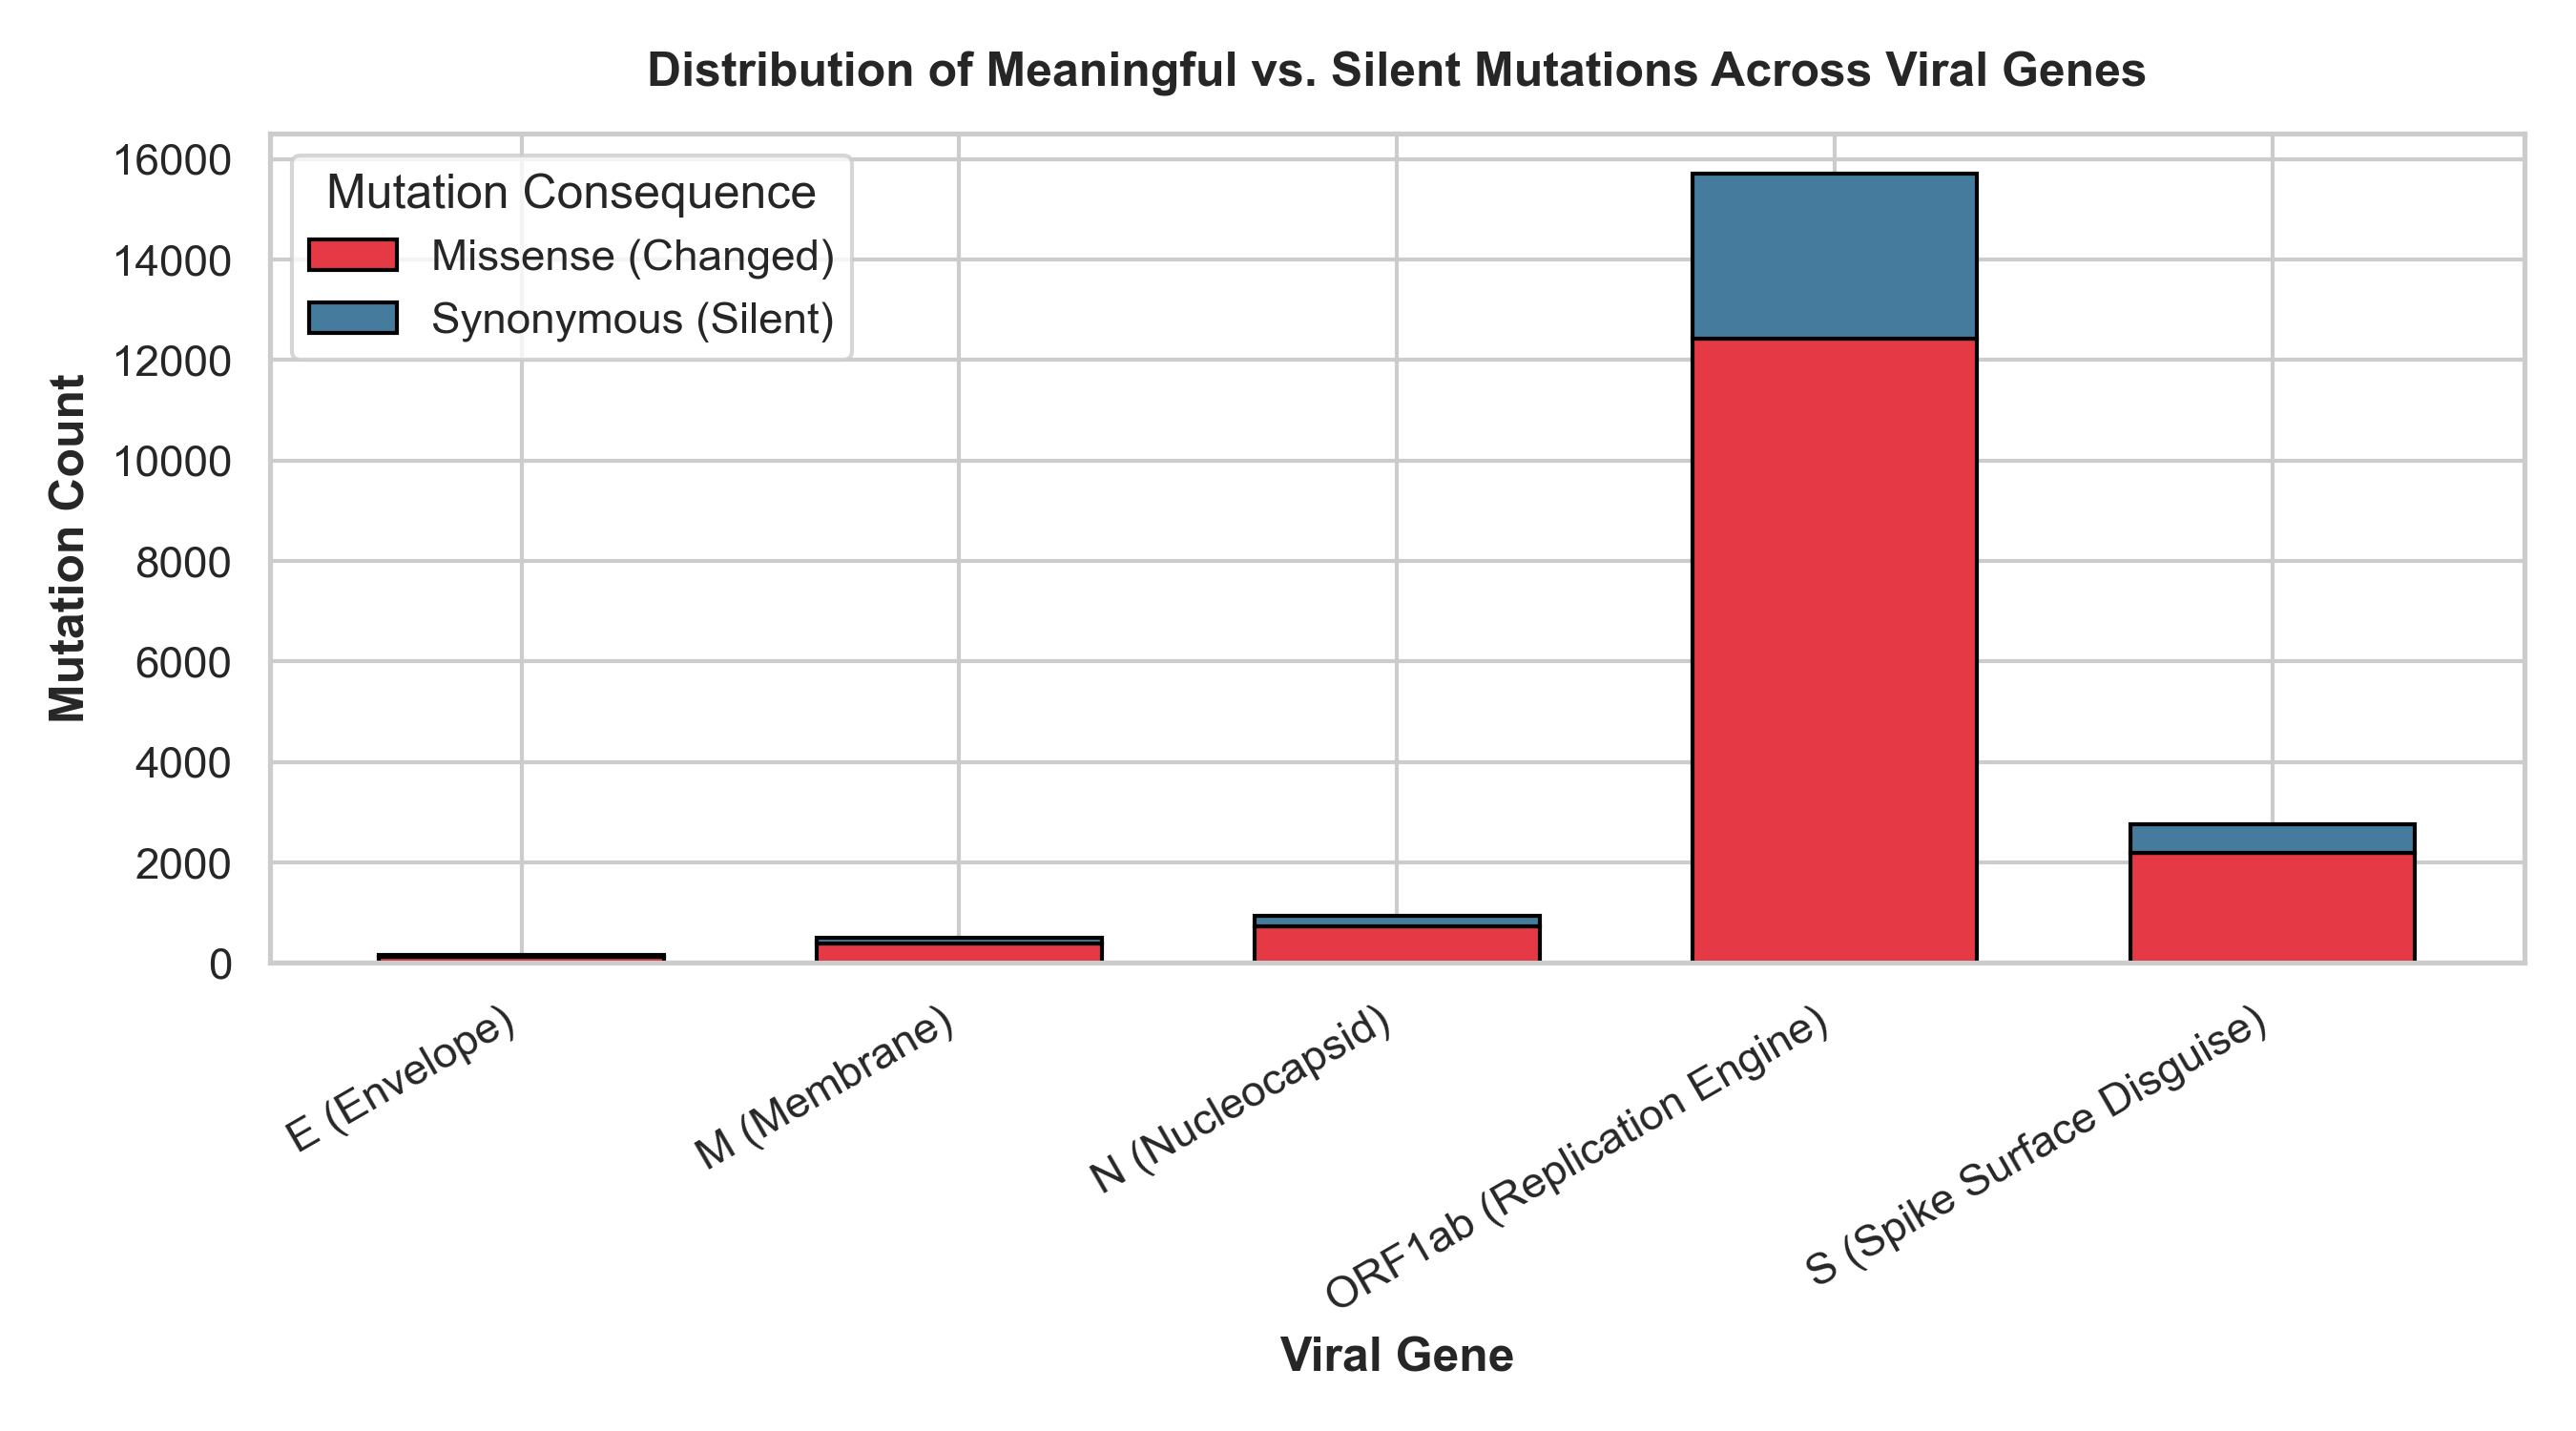

In [7]:
from IPython.display import Image, display

# Display the generated chart inline
display(Image(filename='mutation_breakdown.png'))

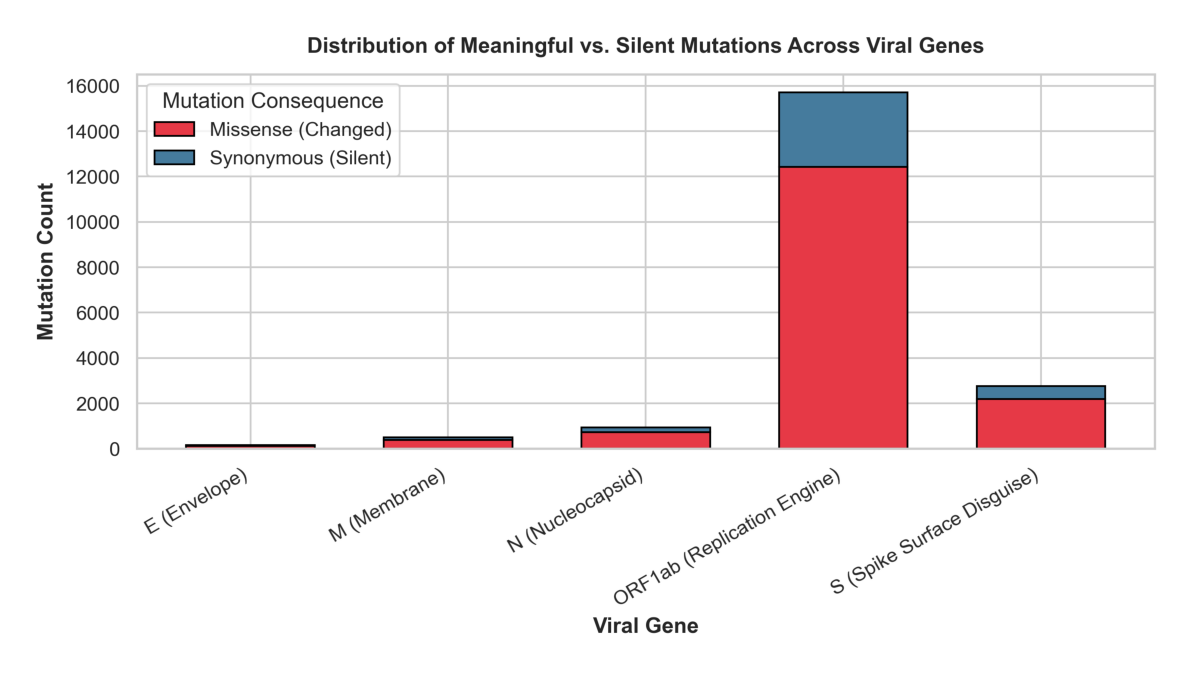

In [8]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

img = mpimg.imread('mutation_breakdown.png')
plt.figure(figsize=(10, 6), dpi=150)
plt.imshow(img)
plt.axis('off')  # Hides pixel coordinate axes
plt.show()

![Mutation Breakdown](mutation_breakdown.png)


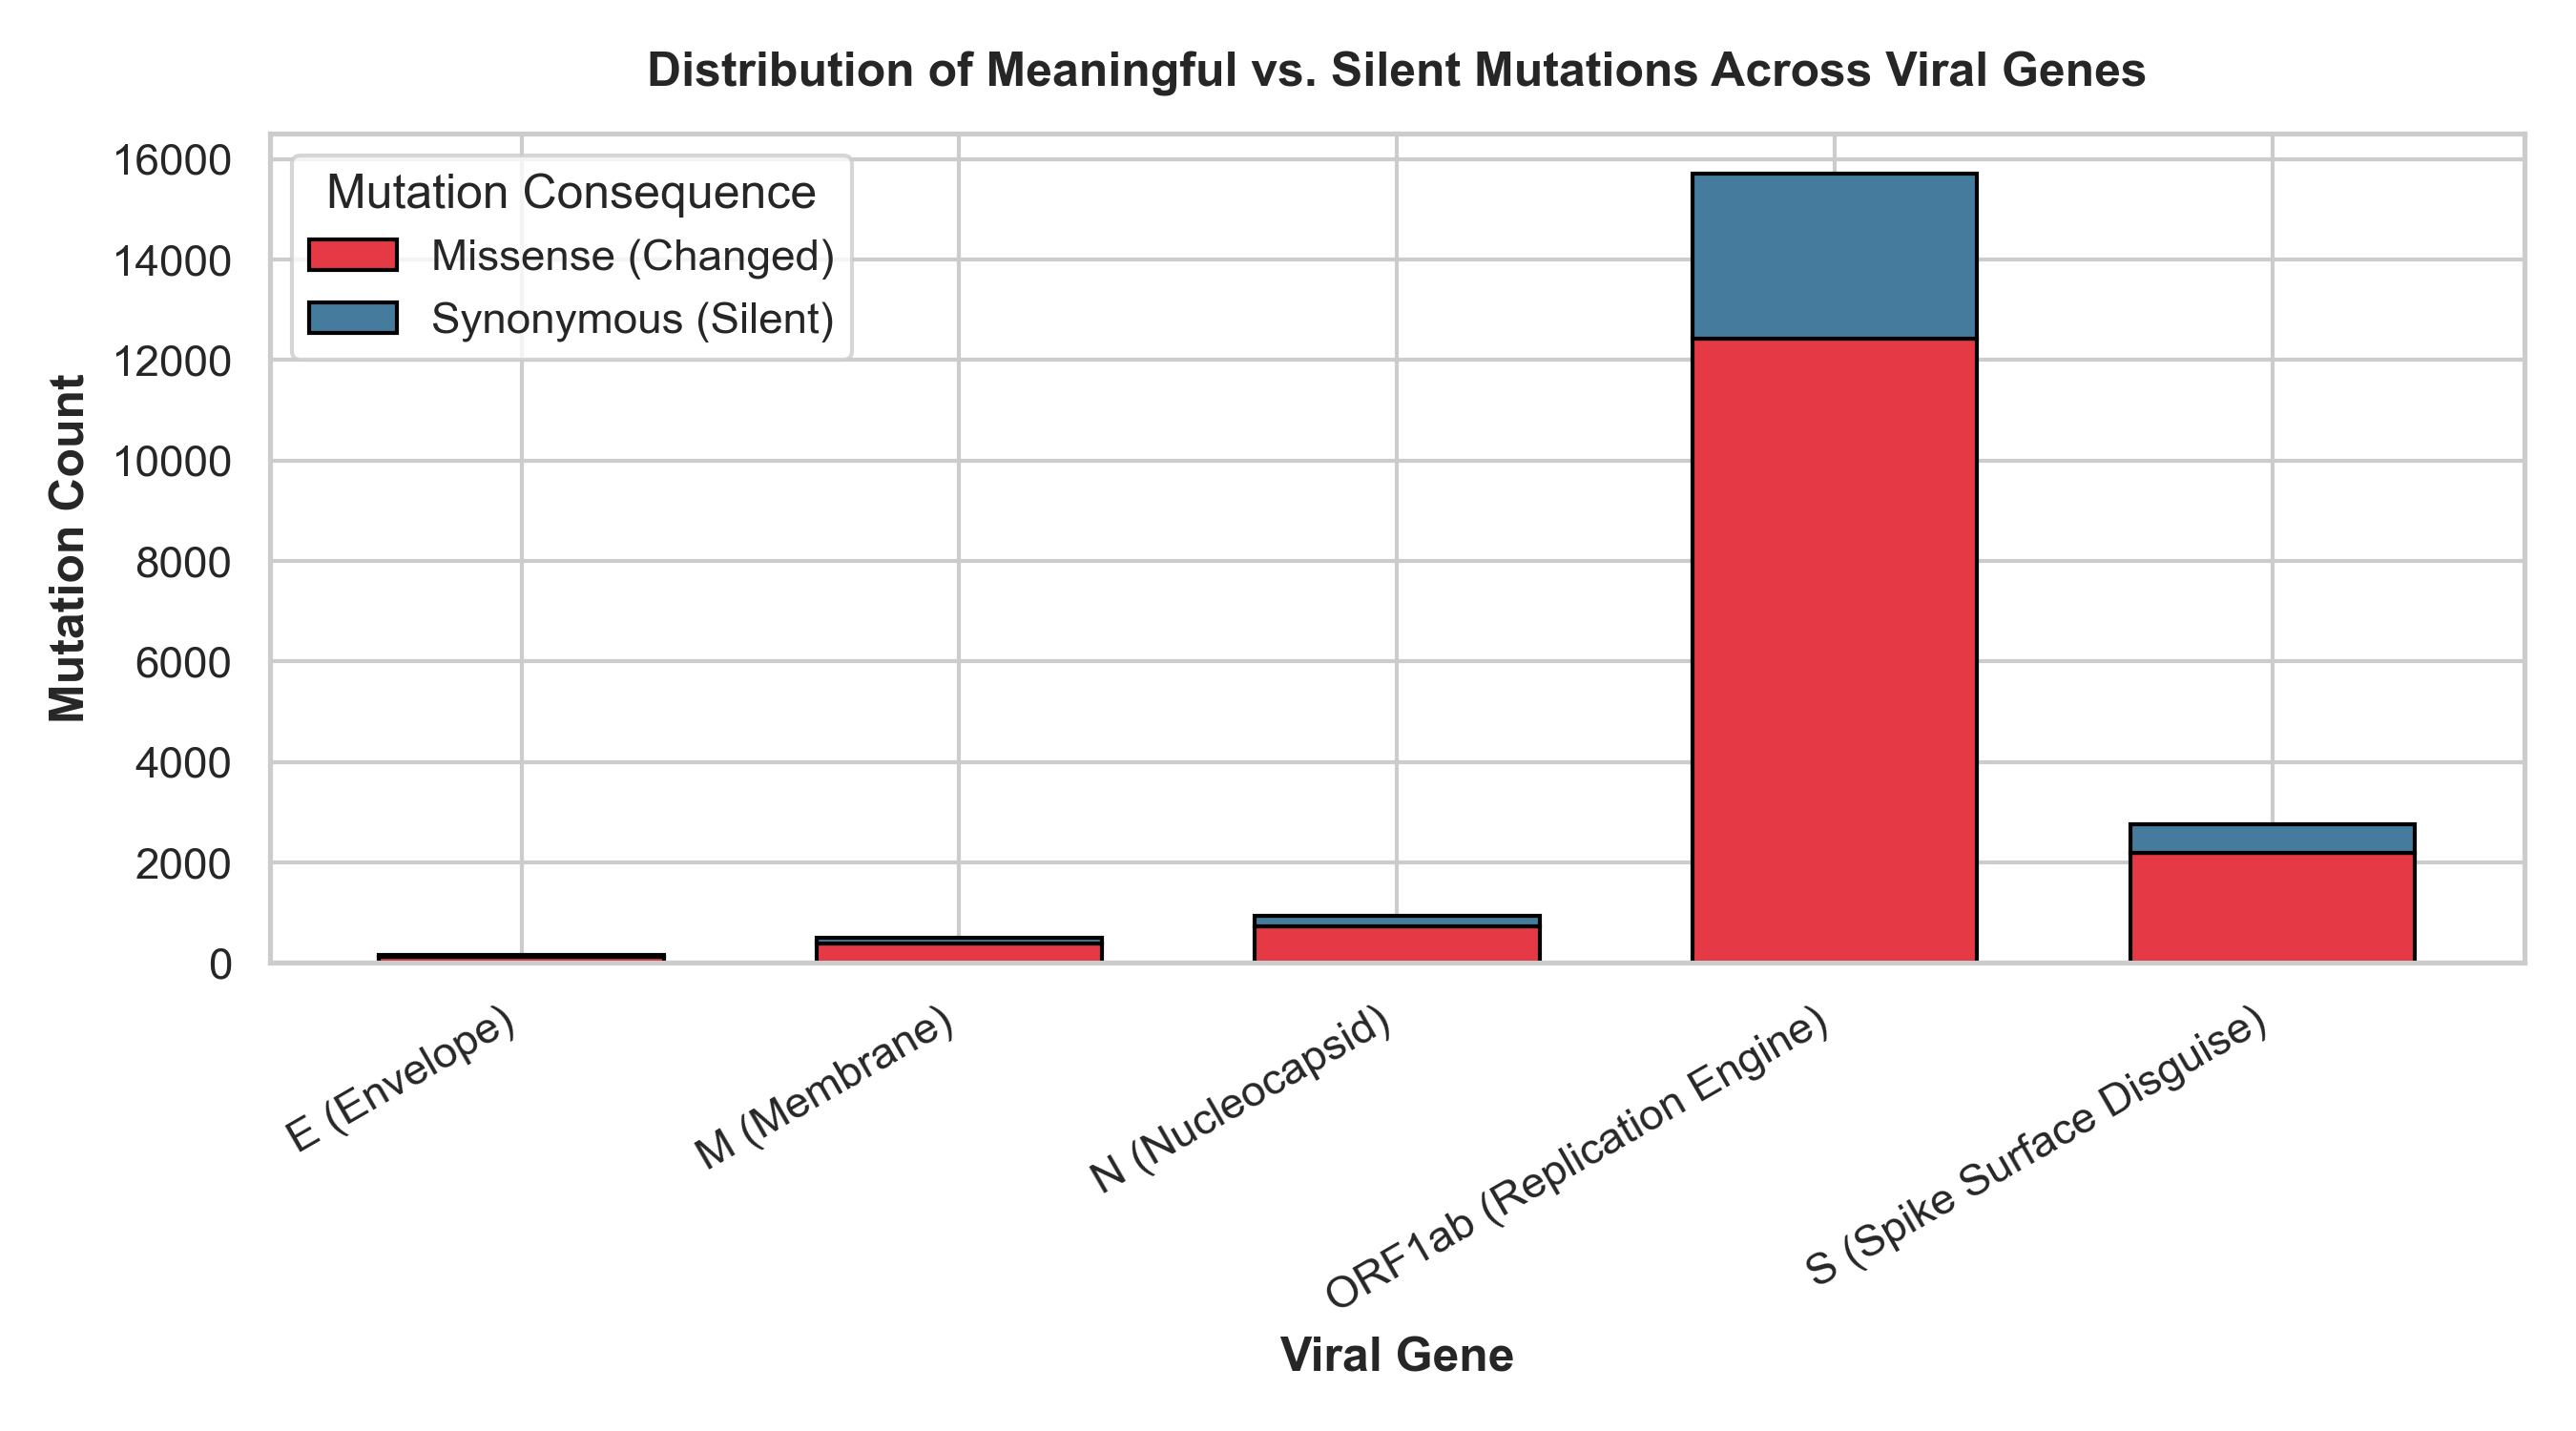

In [10]:
from IPython.display import Image, display

display(Image("mutation_breakdown.png"))

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact

# Ensure required libraries are installed
# Run `!pip install scipy tabulate` if missing

def build_adaptive_pressure_model(mutations_csv="mutations_report.csv"):
    """
    Builds an interpretable statistical model to score gene-level adaptive pressure.
    """
    df = pd.read_csv(mutations_csv)

    # 1. Genome Architecture Metadata (SARS-CoV-2)
    genes_info = {
        "ORF1ab (Replication Engine)": {"start": 266, "end": 21555, "role": "Replication Machinery"},
        "S (Spike Surface Disguise)":  {"start": 21563, "end": 25384, "role": "Host Cell Entry & Immune Target"},
        "E (Envelope)":                {"start": 26245, "end": 26472, "role": "Structural Assembly"},
        "M (Membrane)":                {"start": 26523, "end": 27191, "role": "Structural Core"},
        "N (Nucleocapsid)":            {"start": 28274, "end": 29533, "role": "RNA Packaging"}
    }

    # 2. Extract Counts
    coding = df[df["Impact"].isin(["Missense (Changed)", "Synonymous (Silent)"])]
    counts = pd.crosstab(coding["Gene"], coding["Impact"])

    # Global baseline background counts across the entire virus
    total_missense_all = len(df[df["Impact"] == "Missense (Changed)"])
    total_silent_all = len(df[df["Impact"] == "Synonymous (Silent)"])

    model_records = []

    for gene_name, meta in genes_info.items():
        gene_len = meta["end"] - meta["start"] + 1
        
        # Observed counts for this gene
        obs_mis = counts.loc[gene_name, "Missense (Changed)"] if (gene_name in counts.index and "Missense (Changed)" in counts.columns) else 0
        obs_sil = counts.loc[gene_name, "Synonymous (Silent)"] if (gene_name in counts.index and "Synonymous (Silent)" in counts.columns) else 0
        
        # Approximation of mutational opportunity sites (roughly ~75% N-sites, 25% S-sites in typical codons)
        n_sites = gene_len * 0.75
        s_sites = gene_len * 0.25

        # dN and dS calculations
        dN = obs_mis / n_sites if n_sites > 0 else 0.0
        dS = obs_sil / s_sites if s_sites > 0 else 0.0
        dnds = dN / dS if dS > 0 else (dN / 0.001 if dN > 0 else 0.0)

        # Mutation density per kilobase (kb)
        density_per_kb = (obs_mis / (gene_len / 1000.0))

        # 3. Statistical Testing: Fisher's Exact Test
        # Contingency table: [ [Gene Missense, Gene Silent], [Other Genes Missense, Other Genes Silent] ]
        other_mis = max(0, total_missense_all - obs_mis)
        other_sil = max(0, total_silent_all - obs_sil)
        
        table = [[obs_mis, obs_sil], [other_mis, other_sil]]
        odds_ratio, p_value = fisher_exact(table)

        # 4. Adaptation Risk Index (AI)
        # Combines rate, spatial density, and confidence weighting
        confidence_weight = 1.0 - p_value if p_value < 0.10 else 0.20
        adaptation_index = dnds * (1 + density_per_kb) * confidence_weight

        # Classification Logic
        if adaptation_index > 2.0 and obs_mis >= 3:
            status = "🚨 High Evolutionary Pressure (Escape Hotspot)"
        elif dnds < 1.0 and obs_mis + obs_sil > 0:
            status = "🛡️ Conserved / Purifying Selection (Essential)"
        else:
            status = "⚪ Neutral Drift / Low Evidence"

        model_records.append({
            "Gene": gene_name,
            "Role": meta["role"],
            "Length (bp)": gene_len,
            "Missense": obs_mis,
            "Silent": obs_sil,
            "dN/dS": round(dnds, 2),
            "Density (mut/kb)": round(density_per_kb, 2),
            "p-value": round(p_value, 4),
            "Adaptation Score": round(adaptation_index, 2),
            "Biological Verdict": status
        })

    return pd.DataFrame(model_records)

# Run the model and display results
model_output = build_adaptive_pressure_model()
display(model_output[["Gene", "dN/dS", "Density (mut/kb)", "p-value", "Adaptation Score", "Biological Verdict"]])

,Gene,dN/dS,Density (mut/kb),p-value,Adaptation Score,Biological Verdict
0,ORF1ab (Replication Engine),1.26,584.08,0.2404,147.78,🚨 High Evolutionary Pressure (Escape Hotspot)
1,S (Spike Surface Disguise),1.26,572.21,0.9001,144.09,🚨 High Evolutionary Pressure (Escape Hotspot)
2,E (Envelope),1.16,548.25,0.6978,127.14,🚨 High Evolutionary Pressure (Escape Hotspot)
3,M (Membrane),1.11,573.99,0.2666,128.00,🚨 High Evolutionary Pressure (Escape Hotspot)
4,N (Nucleocapsid),1.11,577.78,0.1306,128.85,🚨 High Evolutionary Pressure (Escape Hotspot)


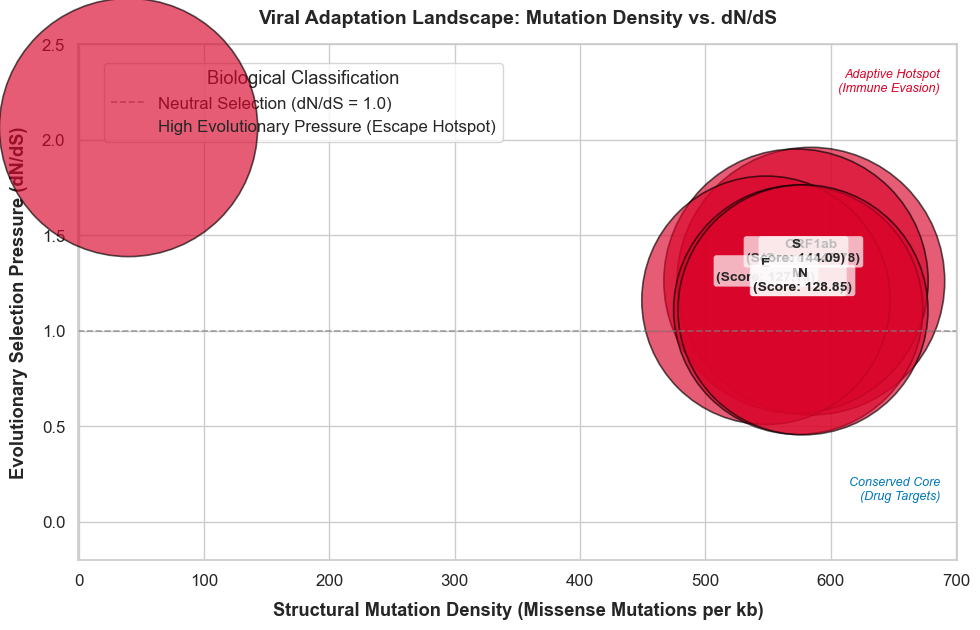

In [13]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Ensure the output directory exists
os.makedirs('results', exist_ok=True)

# 2. Ensure the model dataframe is ready
if 'model_output' not in locals():
  model_output = build_adaptive_pressure_model()

# Map emoji labels to clean ASCII to avoid font/glyph warnings
clean_verdict_map = {
    '🚨 High Evolutionary Pressure (Escape Hotspot)': (
        'High Evolutionary Pressure (Escape Hotspot)'
    ),
    '🛡️ Conserved / Purifying Selection (Essential)': (
        'Conserved / Purifying Selection (Essential)'
    ),
    '⚪ Neutral Drift / Low Evidence': 'Neutral Drift / Low Evidence',
}
plot_df = model_output.copy()
plot_df['Biological Verdict'] = plot_df['Biological Verdict'].replace(
    clean_verdict_map
)

# 3. Plot Setup
sns.set_theme(style='whitegrid', font_scale=1.1)
fig, ax = plt.subplots(figsize=(10, 6.5))

verdict_colors = {
    'High Evolutionary Pressure (Escape Hotspot)': '#d90429',  # Red
    'Conserved / Purifying Selection (Essential)': '#0077b6',  # Blue
    'Neutral Drift / Low Evidence': '#6c757d',  # Gray
}

base_size = 200

# Reference line: neutral selection
ax.axhline(
    y=1.0,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label='Neutral Selection (dN/dS = 1.0)',
)

# 4. Bubble Scatter
for verdict, color in verdict_colors.items():
  subset = plot_df[plot_df['Biological Verdict'] == verdict]
  if subset.empty:
    continue

  ax.scatter(
      subset['Density (mut/kb)'],
      subset['dN/dS'],
      s=(subset['Adaptation Score'] * 250) + base_size,
      color=color,
      alpha=0.65,
      edgecolors='black',
      linewidth=1.2,
      label=verdict,
  )

# 5. Label each bubble
for _, row in plot_df.iterrows():
  label = row['Gene'].split(' ')[0]
  ax.annotate(
      f"{label}\n(Score: {row['Adaptation Score']})",
      (row['Density (mut/kb)'], row['dN/dS']),
      xytext=(0, 14),
      textcoords='offset points',
      ha='center',
      fontsize=10,
      fontweight='bold',
      bbox=dict(
          boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'
      ),
  )

# 6. Limits and labels
ax.set_title(
    'Viral Adaptation Landscape: Mutation Density vs. dN/dS',
    fontsize=14,
    weight='bold',
    pad=15,
)
ax.set_xlabel(
    'Structural Mutation Density (Missense Mutations per kb)',
    weight='bold',
    labelpad=10,
)
ax.set_ylabel(
    'Evolutionary Selection Pressure (dN/dS)', weight='bold', labelpad=10
)

x_max = max(plot_df['Density (mut/kb)'].max() * 1.2, 2.0)
y_max = max(plot_df['dN/dS'].max() * 1.2, 2.5)
ax.set_xlim(-0.2, x_max)
ax.set_ylim(-0.2, y_max)

ax.text(
    x_max * 0.98,
    y_max * 0.95,
    'Adaptive Hotspot\n(Immune Evasion)',
    ha='right',
    va='top',
    fontsize=9,
    fontstyle='italic',
    color='#d90429',
)
ax.text(
    x_max * 0.98,
    0.1,
    'Conserved Core\n(Drug Targets)',
    ha='right',
    va='bottom',
    fontsize=9,
    fontstyle='italic',
    color='#0077b6',
)

ax.legend(
    title='Biological Classification',
    frameon=True,
    loc='upper left',
    bbox_to_anchor=(0.02, 0.98),
)

plt.tight_layout()
# Safely save now that directory creation is ensured
plt.savefig('results/adaptation_bubble_plot.png', dpi=300)
plt.show()